# Lab 13: SVM, ROC and AUC

Built-in breast-cancer dataset; pipeline prevents scaling leakage. ROC positive class is benign (label 1). Educational model, not a medical diagnostic tool.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
Path('figures').mkdir(exist_ok=True)


Accuracy: 0.9790209790209791
ROC AUC: 0.9968553459119497
Positive ROC class: benign (label 1)


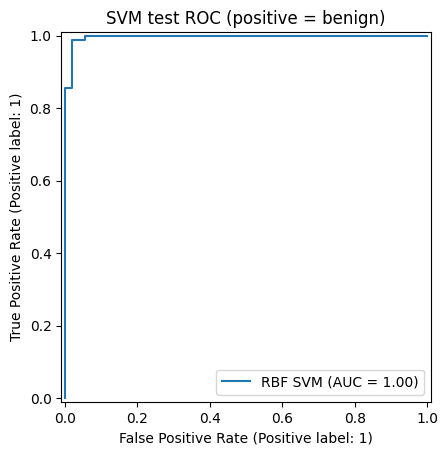

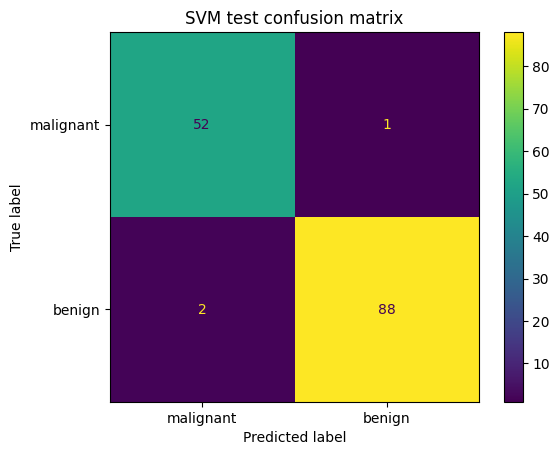

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,roc_auc_score,RocCurveDisplay,ConfusionMatrixDisplay
D=load_breast_cancer();X_train,X_test,y_train,y_test=train_test_split(D.data,D.target,test_size=.25,random_state=42,stratify=D.target)
model=make_pipeline(StandardScaler(),SVC(kernel='rbf',random_state=42));model.fit(X_train,y_train);pred=model.predict(X_test);scores=model.decision_function(X_test)
print('Accuracy:',accuracy_score(y_test,pred));print('ROC AUC:',roc_auc_score(y_test,scores));print('Positive ROC class: benign (label 1)')
RocCurveDisplay.from_predictions(y_test,scores,name='RBF SVM');plt.title('SVM test ROC (positive = benign)');plt.show()
ConfusionMatrixDisplay.from_predictions(y_test,pred,display_labels=D.target_names);plt.title('SVM test confusion matrix');plt.show()
